In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 수정용 변수
video = 'tracking2.avi'
video_image = "video_img.jpg"

# 초기값 변수
cap = cv2.VideoCapture(video)
font = cv2.FONT_HERSHEY_SIMPLEX
check, is_trackbar = False, False
is_running = True
color = []
h, s, v =0,0,0
ix, iy = 0, 0

### 동영상의 프레임 저장

In [5]:
while(1):
    # 비디오 불러오기
    a, frame = cap.read()
    if a == False:
        break

    # frame 창 크기 조절
    resized_frame = cv2.resize(frame, (700, 500))
    cv2.imshow('frame',resized_frame)

    k = cv2.waitKey(25) & 0xFF
    if k == 27:
        is_running = False
        break
    if k == ord('s'):
        img_name = video_image
        cv2.imwrite(img_name, frame)
        break
cv2.destroyAllWindows()

### 이미지에서 HSV값 추출

In [6]:
img = cv2.imread(video_image)
height, width = img.shape[:2]
if width > 700 or height > 500:
    img_copy = cv2.resize(img, (700, 500), interpolation=cv2.INTER_AREA)
else:
    img_copy = img.copy()
img_hsv = img_copy.copy()
img_text = img_copy.copy()

def nothing(x):
    pass

def draw_circle(event,x,y,flags,param):
    global hsv_value,check,h,s,v,hsv,ix,iy,h_val, s_val, v_val
    if event == cv2.EVENT_LBUTTONDOWN:
        hsv = cv2.cvtColor(img_hsv, cv2.COLOR_BGR2HSV)
        h, s, v = hsv[y, x]
        h_val, s_val, v_val = 0, 0, 0
        check = True
    elif event == cv2.EVENT_MOUSEMOVE:
        ix, iy = x, y

In [7]:
cv2.namedWindow('image')
cv2.setMouseCallback('image',draw_circle)

while(is_running):
    cv2.imshow('image',img_text)
    img_text = img_copy.copy()

    k = cv2.waitKey(15) & 0xFF

    text = "( x : "+str(ix)+", y : "+str(iy)+" ), ( H : "+str(h)+", S : "+str(s)+", V : "+str(v)+" )"
    cv2.putText(img_text,text,(10,30), font, 1,(255,255,255),1,cv2.LINE_AA)

    if cv2.getWindowProperty('mask', cv2.WND_PROP_VISIBLE) >= 1:
        if not is_trackbar:
            cv2.createTrackbar('h_value','mask',0,89,nothing)
            cv2.createTrackbar('s_value','mask',0,127,nothing)
            cv2.createTrackbar('v_value','mask',0,127,nothing)
            
            # 기본값 설정
            cv2.setTrackbarPos('h_value', 'mask', 10)
            cv2.setTrackbarPos('s_value', 'mask', 100)
            cv2.setTrackbarPos('v_value', 'mask', 100)

            is_trackbar = True
    else:
        is_trackbar = False

    if check == True:
        img_res = img_copy.copy()

        # HSV 최소값과 최댓값 설정
        h_min = np.clip(h - h_val, 0, 179)
        h_max = np.clip(h + h_val, 0, 179)
        s_min = np.clip(s - s_val, 0, 255)
        s_max = np.clip(s + s_val, 0, 255)
        v_min = np.clip(v - v_val, 0, 255)
        v_max = np.clip(v + v_val, 0, 255)

        lower = np.array([h_min, s_min, v_min])
        upper = np.array([h_max, s_max, v_max])

        mask = cv2.inRange(hsv, lower, upper)
        res = cv2.bitwise_and(img_res,img_res, mask= mask)
        cv2.namedWindow('mask')
        cv2.imshow('mask',res)

        if is_trackbar == True:
            h_val = cv2.getTrackbarPos('h_value','mask')
            s_val = cv2.getTrackbarPos('s_value','mask')
            v_val = cv2.getTrackbarPos('v_value','mask')

        if k == ord('n'):
            cv2.destroyWindow('mask')
            h,s,v = 0,0,0
            check = False
        elif k == ord('y'):
            break
    
    if k == 27:
        is_running = False
        break

cv2.destroyAllWindows()

### 확인

In [8]:
cap.release() # 비디오 연결 해제
cap = cv2.VideoCapture(video) # 비디오 재 연결

while(is_running):
    a, frame = cap.read()

    # 비오디 끝나면 종료
    if a == False:
        break

    # 각 마스크 크기 조절
    resized_frame = cv2.resize(frame, (700, 500))

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower, upper)
    resized_mask = cv2.resize(mask, (700, 500))
    res = cv2.bitwise_and(frame,frame, mask= mask)
    resized_res = cv2.resize(res, (700, 500))

    cv2.imshow('frame',resized_frame)
    cv2.imshow('mask',resized_mask)
    cv2.imshow('res',resized_res)

    k = cv2.waitKey(25) & 0xFF
    if k == 27:
        is_running = False
        break

cv2.destroyAllWindows()  

### HSV의 최소값과 최댓값 표시

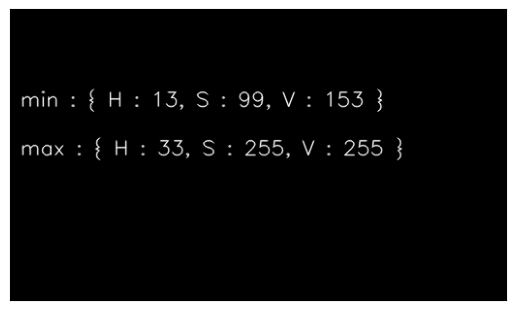

In [9]:
if is_trackbar == True:
    img_info = np.zeros((300, 512, 3), np.uint8)

    text_min = f"min : {{ H : {h_min}, S : {s_min}, V : {v_min} }}"
    text_max = f"max : {{ H : {h_max}, S : {s_max}, V : {v_max} }}"

    cv2.putText(img_info, text_min, (10, 100), font, 0.7, (255, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(img_info, text_max, (10, 150), font, 0.7, (255, 255, 255), 1, cv2.LINE_AA)

    plt.imshow(img_info)
    plt.xticks([]), plt.yticks([])
    plt.show()